

# California Housing — Exploratory Data Analysis & Regression
### Module 1 · Refresher

Welcome! This notebook is your **end-to-end refresher** on the data-science methodology we'll build on all
semester — read, explore, split, scale, model, and evaluate — using the **California housing** dataset
(median home value per district). It's designed to *just run*: hit **Runtime → Run all** and follow along.

> **Learning goals.** By the end you can (1) perform a quick EDA on structured data, (2) split and scale the
> right way, (3) fit a baseline plus stronger models, and (4) evaluate them quantitatively *and* visually.

## Setup
Import our standard toolkit. *(On Colab, uncomment the install line if a package is missing.)*

In [1]:
# !pip install -q scikit-learn pandas matplotlib seaborn
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

## 1. Load the data
We pull **California housing** straight from scikit-learn — no file uploads, no Drive mounting, it just works.
The target is `MedHouseVal` (median home value, in $100,000s).

In [2]:
from sklearn.datasets import fetch_california_housing
data = fetch_california_housing(as_frame=True)
df = data.frame                      # features + target in one DataFrame
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 2. Exploratory data analysis
Always interrogate the **shape**, **dtypes**, and **missing values** first — `df.info()` gives all three at once.
Then look at distributions and how features relate to the target.

In [3]:
print("Shape:", df.shape)
df.info()
df.describe().T

Shape: (20640, 9)
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
MedHouseVal,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


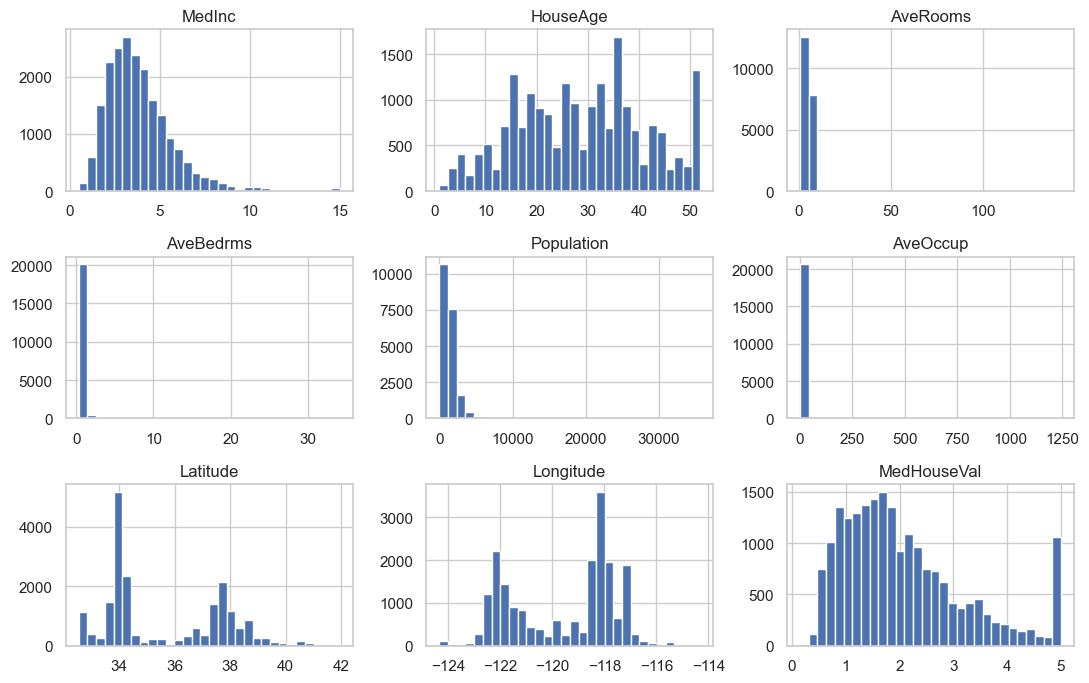

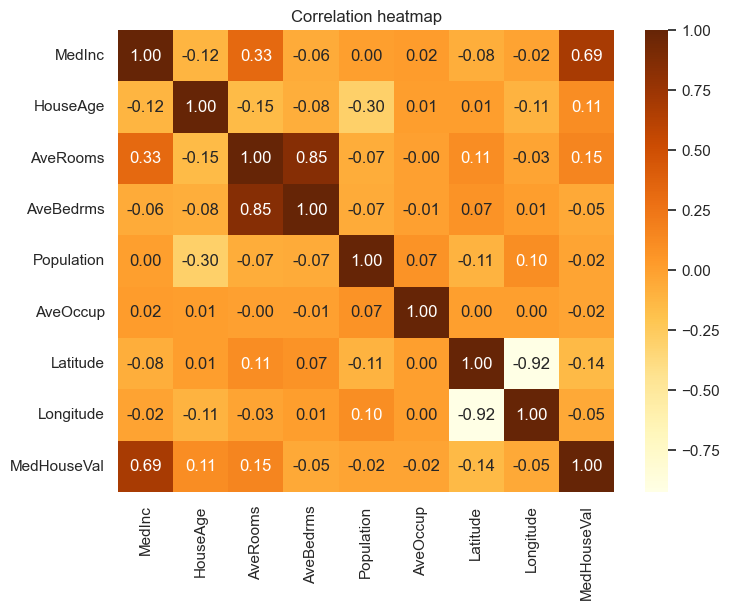

In [4]:
# distributions + correlation with the target
df.hist(figsize=(11, 7), bins=30); plt.tight_layout(); plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="YlOrBr")
plt.title("Correlation heatmap"); plt.show()

## 3. Prepare, split, and scale
Separate features `X` from the target `y`, split into train/test, then **fit the scaler on the training data
only** and apply it to both — our first and most important defense against data leakage.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

y = df["MedHouseVal"]
X = df.drop(columns="MedHouseVal")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)   # FIT on train
X_test  = scaler.transform(X_test)        # only TRANSFORM test
print("train:", X_train.shape, " test:", X_test.shape)

train: (16512, 8)  test: (4128, 8)


## 4. Fit models
Fitting is famously three lines — instantiate, fit, predict — so we fit a **baseline** (linear regression) and a
few stronger tree-based models and compare them on the test set.

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

models = {
    "LinearRegression":          LinearRegression(),
    "DecisionTreeRegressor":     DecisionTreeRegressor(random_state=42),
    "RandomForestRegressor":     RandomForestRegressor(random_state=42),
    "GradientBoostingRegressor": GradientBoostingRegressor(random_state=42),
}
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results[name] = preds
    print(f"{name:28s}  R2={r2_score(y_test, preds):.3f}  "
          f"MAE={mean_absolute_error(y_test, preds):.3f}  "
          f"RMSE={mean_squared_error(y_test, preds) ** 0.5:.3f}")

LinearRegression              R2=0.576  MAE=0.533  RMSE=0.746
DecisionTreeRegressor         R2=0.622  MAE=0.454  RMSE=0.703


RandomForestRegressor         R2=0.805  MAE=0.327  RMSE=0.505


GradientBoostingRegressor     R2=0.776  MAE=0.372  RMSE=0.542


## 5. Evaluate
Numbers tell you *which* model is best; a **predicted-vs-actual** plot tells you *how* it's wrong. A good model
hugs the 45° line.

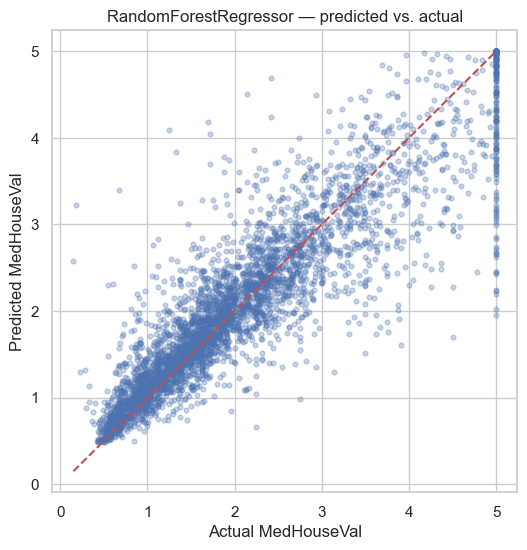

In [7]:
best = "RandomForestRegressor"
preds = results[best]
plt.figure(figsize=(6, 6))
plt.scatter(y_test, preds, alpha=0.3, s=12)
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, "r--")
plt.xlabel("Actual MedHouseVal"); plt.ylabel("Predicted MedHouseVal")
plt.title(f"{best} — predicted vs. actual"); plt.show()

## Takeaways
- The methodology is fixed: **read → split → scale-on-train → fit → evaluate** — every model in the course rides on it.
- **Scale on train, transform test** to avoid leakage.
- Evaluate **quantitatively (R²/MAE/RMSE)** *and* **visually (predicted-vs-actual)**; compare train vs test to catch overfitting.
- Tree ensembles usually beat a linear baseline on this data — but always check the picture, not just the number.